# Jar Growth Intern Assignment

**Jegadeesh D**

This notebook answers all three questions in Python, with the code and its output side by side.

- **Question 1 (30 marks):** sales analysis, in three parts.
- **Question 2 (10 marks):** Jar app exploration.
- **Question 3 (10 marks):** new business opportunities for Jar.

The same results are published as an interactive dashboard: https://jegadeesh17.github.io/GrowthInternJar/

Run it from the repository root after `pip install -r requirements.txt`.

## Setup and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.options.display.float_format = "{:,.2f}".format

orders = pd.read_excel("data/input/List of Orders.xlsx").dropna(subset=["Order ID"])
details = pd.read_excel("data/input/Order Details.xlsx")
targets = pd.read_excel("data/input/Sales target.xlsx")

print("List of Orders:", orders.shape)
print("Order Details: ", details.shape)
print("Sales target:  ", targets.shape)

List of Orders: (500, 5)
Order Details:  (1500, 6)
Sales target:   (36, 3)


### Two date problems in the files

**Order dates.** The dates are written day-first (`13-04-2018`). Excel stored the ones it could read as month-first as real dates with day and month swapped, and left the rest as text.

In [2]:
kinds = orders["Order Date"].map(lambda v: "text, day-first" if isinstance(v, str) else "stored as a date, day and month swapped")
print(kinds.value_counts().to_string())


def fix_order_date(value):
    if isinstance(value, str):
        return pd.to_datetime(value, format="%d-%m-%Y")
    # Excel read DD-MM as MM-DD, so swap them back
    return pd.Timestamp(year=value.year, month=value.day, day=value.month)


orders["Order Date"] = orders["Order Date"].map(fix_order_date)
print()
print("Orders run from", orders["Order Date"].min().date(), "to", orders["Order Date"].max().date())

Order Date
text, day-first                            307
stored as a date, day and month swapped    193

Orders run from 2018-04-01 to 2019-03-31


After the fix every order falls between April 2018 and March 2019, which is exactly the 12 months in the target file. Without it, sales would be spread over 23 months and the monthly comparison in Part 2 would be wrong.

**Target months.** `Apr-18` means April 2018, but Excel stored it as the 18th of April. I read the month as the month and the day as the year.

In [3]:
targets["Month"] = targets["Month of Order Date"].map(lambda d: pd.Period(year=2000 + d.day, month=d.month, freq="M"))
targets[["Month of Order Date", "Month", "Category", "Target"]].head(3)

,Month of Order Date,Month,Category,Target
0,2026-04-18,2018-04,Furniture,10400
1,2026-05-18,2018-05,Furniture,10500
2,2026-06-18,2018-06,Furniture,10600


---
# Question 1: Sales analysis

## Part 1: Sales and profitability

**Merge the two order files on Order ID and total the sales for each category.**

In [4]:
df = details.merge(orders, on="Order ID", how="inner")
print(len(df), "line items across", df["Order ID"].nunique(), "orders after the merge")

category = df.groupby("Category").agg(
    total_sales=("Amount", "sum"),
    total_profit=("Profit", "sum"),
    orders=("Order ID", "nunique"),
)
category[["total_sales"]]

1500 line items across 500 orders after the merge


,total_sales
Category,
Clothing,139054
Electronics,165267
Furniture,127181


**Average profit per order and profit margin for each category.**

- Average profit per order = the category's profit divided by the number of distinct orders that contain it.
- Profit margin = profit as a percentage of Amount.

In [5]:
category["avg_profit_per_order"] = category["total_profit"] / category["orders"]
category["profit_margin_pct"] = category["total_profit"] / category["total_sales"] * 100
category = category.sort_values("profit_margin_pct", ascending=False)
category

,total_sales,total_profit,orders,avg_profit_per_order,profit_margin_pct
Category,,,,,
Clothing,139054,11163,393,28.40,8.03
Electronics,165267,10494,204,51.44,6.35
Furniture,127181,2298,186,12.35,1.81


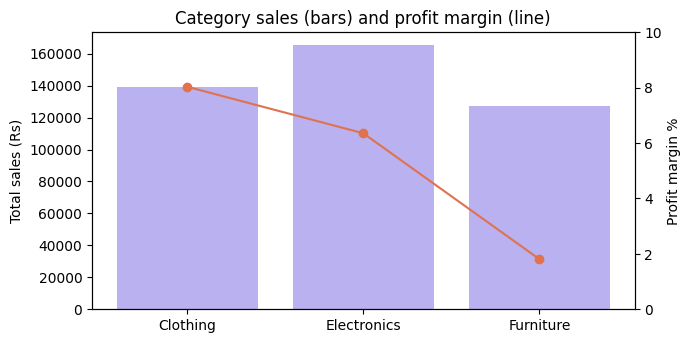

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(category.index, category["total_sales"], color="#b9b1f0")
ax.set_ylabel("Total sales (Rs)")
ax2 = ax.twinx()
ax2.plot(category.index, category["profit_margin_pct"], color="#e0724f", marker="o")
ax2.set_ylabel("Profit margin %")
ax2.set_ylim(0, 10)
ax.set_title("Category sales (bars) and profit margin (line)")
plt.show()

**Top and underperforming categories.**

In [7]:
best_margin = category["profit_margin_pct"].idxmax()
best_per_order = category["avg_profit_per_order"].idxmax()
weakest = category["profit_margin_pct"].idxmin()

print(f"Top on margin:           {best_margin} ({category.loc[best_margin, 'profit_margin_pct']:.1f}%)")
print(f"Top on profit per order: {best_per_order} (Rs {category.loc[best_per_order, 'avg_profit_per_order']:.0f} per order, and the highest sales)")
print(f"Underperformer:          {weakest} ({category.loc[weakest, 'profit_margin_pct']:.1f}% margin, "
      f"Rs {category.loc[weakest, 'avg_profit_per_order']:.0f} per order, lowest on both)")

Top on margin:           Clothing (8.0%)
Top on profit per order: Electronics (Rs 51 per order, and the highest sales)
Underperformer:          Furniture (1.8% margin, Rs 12 per order, lowest on both)


**Why they differ.** The category totals hide large differences between sub-categories, so I broke them down.

In [8]:
sub = df.groupby(["Category", "Sub-Category"]).agg(
    sales=("Amount", "sum"),
    profit=("Profit", "sum"),
    orders=("Order ID", "nunique"),
)
sub["avg_order_value"] = sub["sales"] / sub["orders"]
sub["profit_per_order"] = sub["profit"] / sub["orders"]
sub["margin_pct"] = sub["profit"] / sub["sales"] * 100
sub.sort_values("margin_pct")

sales  profit  orders  avg_order_value  \
Category    Sub-Category                                               
Furniture   Tables            22614   -4011      16         1,413.38   
Electronics Electronic Games  39168   -1236      73           536.55   
Clothing    Saree             53511     352     156           343.02   
Furniture   Chairs            34222     577      64           534.72   
Electronics Phones            46119    2207      71           649.56   
Clothing    Kurti              3361     181      41            81.98   
Furniture   Furnishings       13484     844      66           204.30   
            Bookcases         56861    4888      72           789.74   
Clothing    Trousers          30039    2847      37           811.86   
Electronics Printers          58252    5964      67           869.43   
Clothing    Skirt              1946     235      56            34.75   
            Leggings           2106     260      49            42.98   
            Stole             18546    2559     157           118.13   
            Hankerchief       14608    2098     138           105.86   
            Shirt              7555    1131      66           114.47   
Electronics Accessories       21728    3559      65           334.28   
Clothing    T-shirt            7382    1500      70           105.46   

                              profit_per_order  margin_pct  
Category    Sub-Category                                    
Furniture   Tables                     -250.69      -17.74  
Electronics Electronic Games            -16.93       -3.16  
Clothing    Saree                         2.26        0.66  
Furniture   Chairs                        9.02        1.69  
Electronics Phones                       31.08        4.79  
Clothing    Kurti                         4.41        5.39  
Furniture   Furnishings                  12.79        6.26  
            Bookcases                    67.89        8.60  
Clothing    Trousers                     76.95        9.48  
Electronics Printers                     89.01       10.24  
Clothing    Skirt                         4.20       12.08  
            Leggings                      5.31       12.35  
            Stole                        16.30       13.80  
            Hankerchief                  15.20       14.36  
            Shirt                        17.14       14.97  
Electronics Accessories                  54.75       16.38  
Clothing    T-shirt                      21.43       20.32

In [9]:
# Written findings come from the project's pipeline (src/), which also feeds the dashboard.
# A cross-check at the end of Question 1 confirms it matches the pandas results in this notebook.
from dataclasses import asdict
from src.data_loader import DataLoader
from src.analytics_engine import AnalyticsEngine

p_orders, p_details, p_targets = DataLoader.load_all(data_dir="data/input")
p_merged = AnalyticsEngine.merge_orders(p_orders, p_details)
p_category = AnalyticsEngine.compute_category_performance(p_merged)
p_furniture = AnalyticsEngine.compute_furniture_target_mom(targets_df=p_targets, merged_df=p_merged)
p_states = AnalyticsEngine.compute_top_states_performance(orders_df=p_orders, merged_df=p_merged, top_n=5)
p_sub = AnalyticsEngine.compute_subcategory_performance(p_merged)
p_cities = AnalyticsEngine.compute_city_priorities(p_merged, p_states)
insights = AnalyticsEngine.build_q1_insights(p_category, p_sub, p_furniture, p_states, p_cities)


def bullets(title, items):
    display(Markdown(f"**{title}**\n\n" + "\n".join(f"- {item}" for item in items)))


bullets("Reasons for the performance differences", insights["part1_reasons"])
bullets("What I would do", insights["part1_recommendations"])

**Reasons for the performance differences**

- Furniture has the thinnest margin (1.8%): Tables loses Rs 4,011 on Rs 22,614 of sales (-17.7% margin). At break-even on Tables, Furniture would earn 5.0%.
- Other lines below half the 5.6% average margin: Electronic Games (Electronics, -3.2%), Saree (Clothing, 0.7%), Chairs (Furniture, 1.7%). Saree is 38% of Clothing sales, holding Clothing to 8.0%.
- Ticket size: high-ticket lines (average order above Rs 334, e.g. Tables, Electronic Games) are 79% of sales at 3.4% margin; low-ticket lines (e.g. T-shirt, Accessories) earn 13.6%.
- Profit per order: Electronics Rs 51 vs Furniture Rs 12; the average Tables order loses Rs 251.

**What I would do**

- Review pricing and costs on Tables (Rs 1,413 average order, Rs 251 lost on each, across 16 orders). The data has no cost or discount columns, so the cause needs checking, but break-even would lift Furniture margin from 1.8% to 5.0%.
- Bundle Electronic Games (-3.2%) with Accessories (16.4% margin), the highest-margin Electronics line, so the basket earns a margin instead of adding loss-making volume.

## Part 2: Target achievement

**Month-over-month percentage change in the Furniture sales target.**

In [10]:
furniture = targets[targets["Category"] == "Furniture"].set_index("Month")[["Target"]].copy()
furniture["target_mom_pct"] = furniture["Target"].pct_change() * 100

actual = df[df["Category"] == "Furniture"].groupby(df["Order Date"].dt.to_period("M"))["Amount"].sum()
furniture["actual_sales"] = actual
furniture["actual_mom_pct"] = furniture["actual_sales"].pct_change() * 100
furniture["achieved_pct"] = furniture["actual_sales"] / furniture["Target"] * 100
furniture

,Target,target_mom_pct,actual_sales,actual_mom_pct,achieved_pct
Month,,,,,
2018-04,10400,NaN,8121,NaN,78.09
2018-05,10500,0.96,6220,-23.41,59.24
2018-06,10600,0.95,5532,-11.06,52.19
2018-07,10800,1.89,3483,-37.04,32.25
2018-08,10900,0.93,9538,173.84,87.50
2018-09,11000,0.92,8704,-8.74,79.13
2018-10,11100,0.91,6766,-22.27,60.95
2018-11,11300,1.80,15165,124.14,134.20
2018-12,11400,0.88,9474,-37.53,83.11


**Months with significant target fluctuations.**

In [11]:
steps = furniture["target_mom_pct"].dropna().sort_values(ascending=False)
largest = steps.head(3).sort_index()
usual = steps.iloc[3:].mean()

print("Largest target changes:")
for month, change in largest.items():
    print(f"  {month.strftime('%b-%y')}: +{change:.2f}%  (target up Rs {furniture['Target'].diff()[month]:.0f})")
print(f"Every other month: +{usual:.2f}% on average (target up Rs 100)")
print()
print(f"The three largest steps are about {largest.mean() / usual:.1f}x the usual one, and they come four months apart.")
print(f"Actual sales are far more volatile: month-over-month changes range from "
      f"{furniture['actual_mom_pct'].min():.0f}% to +{furniture['actual_mom_pct'].max():.0f}%.")
print(f"The target was met in {(furniture['achieved_pct'] >= 100).sum()} of {len(furniture)} months.")

Largest target changes:
  Jul-18: +1.89%  (target up Rs 200)
  Nov-18: +1.80%  (target up Rs 200)
  Mar-19: +1.72%  (target up Rs 200)
Every other month: +0.91% on average (target up Rs 100)

The three largest steps are about 2.0x the usual one, and they come four months apart.
Actual sales are far more volatile: month-over-month changes range from -38% to +174%.
The target was met in 4 of 12 months.


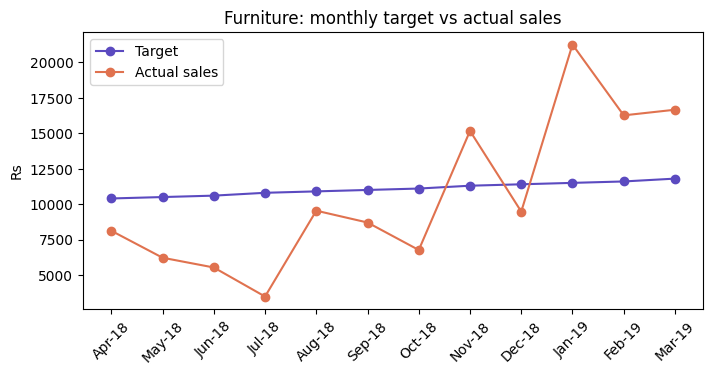

In [12]:
labels = [m.strftime("%b-%y") for m in furniture.index]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(labels, furniture["Target"], color="#5b4ac0", marker="o", label="Target")
ax.plot(labels, furniture["actual_sales"], color="#e0724f", marker="o", label="Actual sales")
ax.set_ylabel("Rs")
ax.set_title("Furniture: monthly target vs actual sales")
ax.legend()
plt.xticks(rotation=45)
plt.show()

**Strategies for aligning targets with actual trends.**

In [13]:
display(Markdown(insights["part2_diagnosis"]))
bullets("Strategies", insights["part2_strategies"])

Targets rise a steady 1.2% a month (Rs 10,400 to Rs 11,800) while actual sales swing from Rs 3,483 (Jul-18) to Rs 21,257 (Jan-19). Achievement: 65% in Apr-18 to Sep-18, 125% in Oct-18 to Mar-19; target met in 4 of 12 months.

**Strategies**

- Phase targets by half-year: Oct-18 to Mar-19 brought 67% of actual sales (Rs 85,583 vs Rs 41,598) but only 52% of the target. Splitting the annual Rs 132,900 target 33/67 gives about Rs 7,245 a month for Apr-18 to Sep-18 and Rs 14,905 for Oct-18 to Mar-19. One year of data can't confirm this is seasonal, so treat the split as a starting point.
- Rolling 3-month baseline: setting each target at the previous 3 months' average actual would have missed by Rs 3,434 a month over Jul-18 to Mar-19, vs Rs 4,486 for the current ramp (23% smaller). Latest baseline: Rs 18,059 a month vs a Rs 11,800 target.
- Quarterly re-forecast: achievement ranged from 63% (Apr-18 to Jun-18) to 155% (Jan-19 to Mar-19). Resetting each next quarter's target from the half-year split and latest run-rate stops one quarter's miss or windfall distorting the year.

## Part 3: Regional performance

**Top 5 states by order count (from List of Orders), with total sales and average profit.**

Average profit = the state's profit divided by its number of orders.

In [14]:
top5 = orders.groupby("State")["Order ID"].nunique().nlargest(5)

states = df[df["State"].isin(top5.index)].groupby("State").agg(
    total_sales=("Amount", "sum"),
    total_profit=("Profit", "sum"),
)
states.insert(0, "orders", top5)
states["avg_profit_per_order"] = states["total_profit"] / states["orders"]
states["profit_margin_pct"] = states["total_profit"] / states["total_sales"] * 100
states = states.sort_values("orders", ascending=False)
states

,orders,total_sales,total_profit,avg_profit_per_order,profit_margin_pct
State,,,,,
Madhya Pradesh,101,105140,5551,54.96,5.28
Maharashtra,90,95348,6176,68.62,6.48
Rajasthan,32,21149,1257,39.28,5.94
Gujarat,27,21058,465,17.22,2.21
Punjab,25,16786,-609,-24.36,-3.63


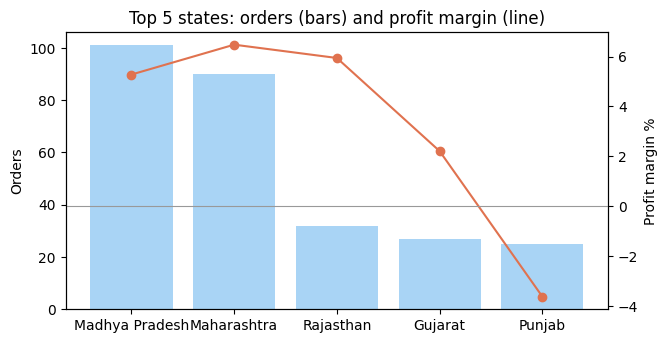

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(states.index, states["orders"], color="#a9d4f5")
ax.set_ylabel("Orders")
ax2 = ax.twinx()
ax2.plot(states.index, states["profit_margin_pct"], color="#e0724f", marker="o")
ax2.axhline(0, color="#999999", linewidth=0.8)
ax2.set_ylabel("Profit margin %")
ax.set_title("Top 5 states: orders (bars) and profit margin (line)")
plt.xticks(rotation=20)
plt.show()

**Regional disparities.** The gaps are wider between cities than between states.

In [16]:
cities = df[df["State"].isin(top5.index)].groupby(["State", "City"]).agg(
    orders=("Order ID", "nunique"),
    sales=("Amount", "sum"),
    profit=("Profit", "sum"),
)
cities["margin_pct"] = cities["profit"] / cities["sales"] * 100
display(cities.sort_values(["State", "sales"], ascending=[True, False]))

bullets("Disparities", insights["part3_disparities"])

orders  sales  profit  margin_pct
State          City                                         
Gujarat        Ahmedabad       17  14230    -880       -6.18
               Surat           10   6828    1345       19.70
Madhya Pradesh Indore          76  79069    4159        5.26
               Bhopal          22  23583     871        3.69
               Delhi            3   2488     521       20.94
Maharashtra    Mumbai          68  61867    1637        2.65
               Pune            22  33481    4539       13.56
Punjab         Chandigarh      16  12279   -1153       -9.39
               Amritsar         9   4507     544       12.07
Rajasthan      Udaipur         13  11073    2010       18.15
               Jaipur          19  10076    -753       -7.47

**Disparities**

- Madhya Pradesh and Maharashtra lead on volume (101 and 90 orders; Rs 105,140 and Rs 95,348 of sales), but Madhya Pradesh earns 5.3% margin vs 6.5%; closing the 1.2-point gap is worth about Rs 1,262 of profit.
- Top-5 margins range from 6.5% (Maharashtra) to -3.6% (Punjab); Punjab loses Rs 609, driven by Chandigarh (-Rs 1,153).
- Gaps are wider within states: in Maharashtra, Mumbai runs at 2.6% margin while Pune earns 13.6%, so the fix is local pricing and mix.

**Cities to prioritise.**

- *Fix*: the cities losing the most profit compared with the overall margin.
- *Scale*: cities with above-median sales and above-average margin.

Most of these cities have fewer than 20 orders, so I treat them as leads to check, not conclusions.

In [17]:
pd.set_option("display.max_colwidth", None)
priorities = pd.DataFrame([asdict(c) for c in p_cities])
priorities[["action", "city", "state", "total_sales", "total_profit", "profit_margin_pct", "reason"]]

,action,city,state,total_sales,total_profit,profit_margin_pct,reason
0,Fix,Chandigarh,Punjab,"12,279.00","-1,153.00",-9.39,"Loses Rs 1,153 on Rs 12,279 of sales (-9.4% margin); biggest drag is Phones (-Rs 1,546)."
1,Fix,Mumbai,Maharashtra,"61,867.00","1,637.00",2.65,65% of Maharashtra sales but only 2.6% margin vs 5.6% overall; biggest drag is Saree (-Rs 801).
2,Fix,Ahmedabad,Gujarat,"14,230.00",-880.00,-6.18,"Loses Rs 880 on Rs 14,230 of sales (-6.2% margin); biggest drag is Bookcases (-Rs 1,049)."
3,Fix,Jaipur,Rajasthan,"10,076.00",-753.00,-7.47,"Loses Rs 753 on Rs 10,076 of sales (-7.5% margin); biggest drag is Phones (-Rs 780)."
4,Fix,Chennai,Tamil Nadu,"6,087.00","-2,216.00",-36.41,"Worst city outside the top states (Tamil Nadu): loses Rs 2,216 on Rs 6,087 of sales (-36.4% margin); biggest drag is Tables (-Rs 1,864)."
5,Scale,Pune,Maharashtra,"33,481.00","4,539.00",13.56,"13.6% margin on Rs 33,481 of sales, led by Printers (Rs 1,416 profit); add volume here."
6,Scale,Allahabad,Uttar Pradesh,"16,857.00","3,081.00",18.28,"18.3% margin on Rs 16,857 of sales, led by Printers (Rs 1,991 profit); add volume here."


### Assumptions in Question 1 and why

- **Order dates:** text dates are read day-first, and the dates Excel converted have day and month swapped back. *Why:* only then do all orders fall in Apr-18 to Mar-19, the 12 months in the target file.
- **Average profit per order** counts an order once for each category it contains. *Why:* one order can hold several lines and categories, and the brief asks for profit per order, not per line.
- **Top performer** is judged on both margin and profit per order. *Why:* the brief names both, and they point to different categories.
- **Significant target fluctuations** are the three largest steps, not a fixed cut-off. *Why:* the target never moves more than 2% in a month, so what stands out is relative to the usual step.
- **Targets re-phased by half-year, checked against a 3-month rolling baseline.** *Why:* the first half fell well short of target and the second half beat it, and three months smooths one odd month while still following the trend.
- **Cities to fix** are ranked by profit shortfall against the overall margin; **cities to scale** need above-median sales and above-average margin. *Why:* the first puts a rupee value on each problem, the second picks cities that are both large and profitable.

### Cross-check: this notebook against the project pipeline

In [18]:
pipe_cat = pd.DataFrame([asdict(c) for c in p_category]).set_index("category")
assert (pipe_cat["total_sales"] == category["total_sales"].reindex(pipe_cat.index)).all()
assert (pipe_cat["profit_margin_pct"] - category["profit_margin_pct"].reindex(pipe_cat.index)).abs().max() < 0.01

pipe_fur = pd.DataFrame([asdict(f) for f in p_furniture])
assert (pipe_fur["actual_sales"].values == furniture["actual_sales"].values).all()
assert (pipe_fur["mom_target_pct_change"].dropna().values - furniture["target_mom_pct"].dropna().values).max() < 0.01

pipe_states = pd.DataFrame([asdict(s) for s in p_states]).set_index("state")
assert (pipe_states["distinct_orders"] == states["orders"].reindex(pipe_states.index)).all()
assert (pipe_states["total_sales"] == states["total_sales"].reindex(pipe_states.index)).all()

print("Category, Furniture and state figures match the pipeline that feeds the dashboard.")

Category, Furniture and state figures match the pipeline that feeds the dashboard.


---
# Question 2: Jar app exploration

I used the Jar Android app in September 2026: I set up saving with UPI AutoPay, made a small test withdrawal, and went through the checkout, round-off, festival saving and notification settings. Where a point comes from Jar's website or store listing instead of what I saw, it says so.

In [19]:
from src.content.ux_teardown import get_ux_teardown_report

ux = get_ux_teardown_report()

text = "## Five things that work well\n"
for i, s in enumerate(ux.strengths, start=1):
    text += (f"\n### {i}. {s.title}\n{s.description}\n\n"
             f"- **Why it works:** {s.behavioral_psychology}\n"
             f"- **Effect on growth:** {s.growth_mechanism}\n"
             f"- **What I would add:** {s.actionable_takeaway}\n"
             f"- **Metric to watch:** {s.primary_impact_metric}\n")
display(Markdown(text))

## Five things that work well

### 1. Automatic saving
You pick an amount once, set up UPI AutoPay, and Jar buys gold for you every day (or week, or month) without you doing anything. A round-off option adds spare change on top: in Jar's own example, a ₹27 spend is rounded up to ₹30 and the ₹3 is saved.

- **Why it works:** Saving is on by default, so it doesn't depend on willpower. Small daily amounts and spare change don't feel like real money, so saving them barely hurts.
- **Effect on growth:** Daily saves create around 30 small deposits a month instead of one monthly SIP, so users have far more reasons to open Jar, which helps retention without ad spend.
- **What I would add:** Suggest raising the daily amount at the right moments (payday, or after 30 days of successful saves), so keen savers can speed up with one tap.
- **Metric to watch:** Share of users still auto-saving after 30 and 90 days; average daily saving amount

### 2. Start with ₹10
You can start saving in 24K gold with ₹10, compared with thousands of rupees for a physical coin. That opens gold up to students, gig workers and first-time savers who would never walk into a jeweller to invest.

- **Why it works:** A tiny first amount removes the fear of losing money, so people try it now instead of putting it off.
- **Effect on growth:** A ₹10 first save is an easy activation step. Once users see their gold balance grow, moving up to a daily auto-save is a much smaller ask.
- **What I would add:** Prompt a daily auto-save straight after the first manual save, while the user is most engaged.
- **Metric to watch:** Install-to-first-save conversion; share of new savers who set up a daily save within 7 days

### 3. Spins, coupons and referral bonuses
The app has spins, coupons and a referral bonus, so using it comes with small wins and there is a reason to bring a friend in.

- **Why it works:** Unpredictable rewards such as a spin keep people coming back more than a fixed reward of the same value would.
- **Effect on growth:** Rewards turn a set-and-forget product into one people have a reason to open, and a referral bonus brings in new savers through someone they already trust.
- **What I would add:** I couldn't find a streak in the app. An extra spin for seven saves in a row would reward consistency, not just single saves.
- **Metric to watch:** Share of spins and coupons redeemed; referred users who make a first save

### 4. Fast withdrawals
When I sold a small test amount of gold, the money reached my bank account in about 3 seconds. First-time investors worry about getting stuck, and a withdrawal that fast removes that worry.

- **Why it works:** Knowing you can get out easily makes it easier to put money in.
- **Effect on growth:** A fast exit lowers the risk of the first deposit, and a user whose first withdrawal goes smoothly is more likely to keep saving.
- **What I would add:** I only tested a small amount. If larger withdrawals are as fast, that speed is worth stating up front when a new saver makes a first deposit.
- **Metric to watch:** Share of users who save again within 30 days of a withdrawal

### 5. Visible trust signals
Jar says the gold is 24K, stored in Brink's vaults and insured by ICICI Lombard, with independent oversight by Vistra, and the app offers delivery of gold coins. For a first-time investor, being able to hold the coin makes digital gold feel real.

- **Why it works:** Gold is already trusted in Indian households; vault details and coin delivery carry that trust over to the app.
- **Effect on growth:** Trust built on small saves is what lets users make bigger purchases later, for example at Dhanteras or Akshaya Tritiya.
- **What I would add:** Keep the vault, insurer and oversight details one tap from the balance screen, since that is where a nervous saver looks.
- **Metric to watch:** Average purchase size around festivals; coin delivery orders


In [20]:
text = "## Five areas to improve\n"
for i, f in enumerate(ux.frictions, start=1):
    fixes = f.actionable_solution.replace("\n", "\n  ")
    text += (f"\n### {i}. {f.title}\n*{f.priority}, effort: {f.implementation_effort}*\n\n{f.description}\n\n"
             f"- **Why it matters:** {f.behavioral_friction}\n"
             f"- **Suggested fix:**\n  {fixes}\n"
             f"- **Metric to watch:** {f.primary_impact_metric}\n")
display(Markdown(text))

## Five areas to improve

### 1. The day-one value drop is easy to miss
*P0 - Critical, effort: Low*

Buying gold includes 3% GST, and the buy and sell prices differ, so ₹100 of gold is worth less than ₹100 if sold straight away. Jar does show the GST breakdown, but inside a dropdown at checkout that is easy to skip, so a new user can still be surprised when their balance is lower than what they paid.

- **Why it matters:** A loss on day one feels bigger than the same gain later, and it's the kind of surprise that leads to complaints and bad reviews.
- **Suggested fix:**
  1. Open the GST breakdown by default on a user's first purchase instead of hiding it in a dropdown.
  2. On the same screen, show in one line what the gold would fetch if sold today, so the gap is seen before paying, not after.
- **Metric to watch:** First-week withdrawals by new users; reviews and tickets mentioning 'loss' or 'deduction'

### 2. Notification controls are too coarse
*P1 - High, effort: Medium*

I have Jar's notifications turned off, and the settings give me no way to turn on only the ones I would want. Inside the app the only choice is a gold price alert. In Android's settings Jar has just two notification categories, an announcements one and 'Miscellaneous', so an alert about my money and a promotion can't be told apart.

- **Why it matters:** When the choice is all or nothing, cautious users choose nothing, and Jar loses its main way to reach them about a failed payment or a goal that is nearly met.
- **Suggested fix:**
  1. Split notifications into clear types (payments and account, gold price, rewards, offers) in the app and as separate Android categories.
  2. When asking for permission, say that offers can be switched off on their own.
- **Metric to watch:** Share of users with notifications on; app opens from notifications

### 3. Round-off is hard to understand
*P1 - High, effort: Low*

I could see the round-off feature but couldn't tell from the screen how it works: which spends it counts, how Jar sees them, or how much it would take in a month.

- **Why it matters:** People don't switch on something that moves their money automatically unless they can predict what it will do.
- **Suggested fix:**
  1. Show one worked example on the round-off screen (a ₹27 spend becomes ₹30, and ₹3 is saved).
  2. Say plainly how Jar detects spends and what it needs access to.
  3. Let users set a monthly cap before switching it on.
- **Metric to watch:** Share of savers who switch on round-off; round-off savings per user per month

### 4. Goal saving stops at festivals
*P1 - High, effort: Medium*

Jar already lets you save towards festivals, which shows goal-based saving works. But the bigger things people save for (a wedding, a child's education, an emergency fund) can't be set up the same way, so that money sits in one balance with no visible progress.

- **Why it matters:** People save more steadily towards a named goal, and seeing progress makes them less likely to withdraw early.
- **Suggested fix:**
  1. Extend festival saving to any named goal, with a target amount, a date and a progress bar.
  2. Add an optional 24-hour wait before withdrawing from a goal.
  3. Let family members add gold to a goal through a shareable link (see Q3).
- **Metric to watch:** Early withdrawal rate; monthly saving of users with goals vs without

### 5. Nothing beyond gold for savers who want to diversify
*P2 - Medium, effort: High*

The app sells silver jewellery, but I found no way to save in silver or in mutual funds (September 2026). Someone who has saved for a year and wants to spread their money has to open another app such as Groww or Zerodha to do it.

- **Why it matters:** Once savings get large, keeping everything in one asset starts to feel risky, and the app a user opens to diversify can become the one they save in.
- **Suggested fix:**
  1. Offer a short list of simple mutual funds, including gold and silver funds, alongside gold (see Q3).
  2. Keep the same set-once, save-automatically flow so it doesn't feel like a different product.
- **Metric to watch:** Balance per user after 12 months; churn of users with large balances


---
# Question 3: New business opportunities

The scale figures below are simple arithmetic on my own assumptions, each with its reason. They are not Jar data.

In [21]:
from src.content.growth_strategy import get_growth_strategy_report

gs = get_growth_strategy_report()

text = f"{gs.priority_note}\n\n## Where I would start\n"
for i, m in enumerate(gs.first_moves, start=1):
    text += (f"\n### {i}. {m['name']}\n{m['why']}\n\n"
             f"- **How to test it:** {m['test']}\n"
             f"- **Success in 90 days:** {m['success']}\n")
display(Markdown(text))

Jar already has gold saving with a festival option, a jewellery brand (Nek) and personal loans (listed on the Play Store; not visible in my app), so I left those out. I also dropped loans against Jar gold: RBI's gold-collateral rules, in force since 1 April 2026, rule out digital gold as collateral. I would start with the two ideas that are cheapest to test.

## Where I would start

### 1. Family goals (Jar Goals)
It extends the festival saving Jar already has, and every contribution introduces Jar to someone new.

- **How to test it:** Before Diwali, give 5% of users named goals with a share link and compare with a control group.
- **Success in 90 days:** Share of goals that get a contribution from someone else; contributors who start saving within 30 days.

### 2. Mutual funds alongside gold (Jar Funds)
Long-term savers can't diversify inside Jar today, and funds are a regulated product.

- **How to test it:** Show a 'Save in funds too' card to users who have saved 6+ months and count waitlist sign-ups before building anything.
- **Success in 90 days:** Waitlist sign-up rate; in a pilot, the share of fund users who keep their gold save running.


In [22]:
text = "## The ideas\n"
for v in gs.verticals:
    risks = "\n".join(f"  - *{r.risk_title}* ({r.severity}): {r.mitigation_strategy}" for r in v.execution_risks)
    kpis = "; ".join(v.primary_kpis)
    text += (f"\n### {v.name}: {v.tagline}\n{v.strategic_rationale}\n\n"
             f"- **Who it is for:** {v.target_persona}\n"
             f"- **How it uses Jar's strengths:** {v.flywheel_integration}\n"
             f"- **How it earns:** {v.how_it_earns}\n"
             f"- **Illustrative scale and assumptions:** {v.illustrative_scale}\n"
             f"- **KPIs:** {kpis}\n"
             f"- **Risks:**\n{risks}\n")
display(Markdown(text))

## The ideas

### Jar Goals: Named goals that family can add to
Jar has festival saving, but I found no way to create any other named goal (September 2026). Let users name a goal such as a wedding or a child's education and share a link, so relatives add gold on birthdays or Diwali instead of giving cash.

- **Who it is for:** Parents saving for their children, and relatives who give cash gifts.
- **How it uses Jar's strengths:** Automation: the daily AutoPay save can point at the goal. Design: the festival saving flow users already know. Credibility: relatives meet Jar through someone they trust.
- **How it earns:** Jar's existing margin on gold, on money that would otherwise be given as cash.
- **Illustrative scale and assumptions:** 200,000 goals x ₹7,500 = ₹150 Cr of gold saved. Assumptions and why: 200,000 is 1 in 250 of the 5 crore+ users on Jar's website, kept small because most users won't set up a goal. ₹7,500 is ₹25 a day for 300 days, a little above the ₹10 minimum because a goal also collects gifts.
- **KPIs:** Goals that receive a contribution from someone else; Contributors who start saving within 30 days; Monthly saving of users with a goal vs without
- **Risks:**
  - *Fake contribution links* (Medium): Show the verified goal owner's name on every link and make links expire.
  - *Goals for minors* (Medium): Keep the goal under the parent's account and KYC.

### Jar Funds: Simple mutual funds alongside gold
Long-term savers want to diversify, and I found no way to save in silver or mutual funds in the app (September 2026). Offer a short list of simple funds (index, liquid, gold and silver) with the same set-once flow. Funds are SEBI-regulated; digital gold is not, as SEBI cautioned in November 2025.

- **Who it is for:** Users who have saved for 6+ months and built a balance.
- **How it uses Jar's strengths:** Automation: the same set-once AutoPay routine, on a separate mandate because fund money must go from the investor's bank to the fund house, not through Jar. Design: a short list in plain words. Credibility: a regulated product inside an app users already trust.
- **How it earns:** Yearly distribution commission from fund houses on the balance held.
- **Illustrative scale and assumptions:** 150,000 savers x ₹500 a month x 12 = ₹90 Cr of balances; at 0.2% a year that is about ₹18 lakh, so this is a retention product first. Assumptions and why: 150,000 is about 1 in 330 of Jar's 5 crore+ users, fewer than for goals because funds need full KYC. ₹500 a month is a common minimum SIP. 0.2% sits in the 0.05-0.25% range distributors typically earn on index and liquid funds.
- **KPIs:** Long-term savers who add a fund; Churn of long-term savers; Fund users who keep their gold save running
- **Risks:**
  - *Licensing and KYC* (High): Register as a distributor with AMFI, and ask for full KYC (PAN) only when a user first picks a fund.
  - *Fund minimums above ₹10* (Medium): Daily fund SIPs usually start near ₹100, so begin with weekly or monthly SIPs.

### Jar Fixed: Fixed deposits with partner banks
Some savers want a fixed return without price swings, which gold can't give, and I found no deposit option in the app (September 2026). Offer fixed deposits from partner banks, as apps such as Stable Money do. The deposit sits with an RBI-regulated bank, not Jar, and carries deposit insurance (DICGC).

- **Who it is for:** Cautious savers, and users about to withdraw a lump sum.
- **How it uses Jar's strengths:** Automation: a withdrawal can be redirected into a deposit, which renews on its own at maturity. Design: the same few taps as a gold save. Credibility: an RBI-regulated bank behind an app the user already trusts.
- **How it earns:** A sourcing fee from the partner bank on each deposit.
- **Illustrative scale and assumptions:** 100,000 savers x ₹10,000 = ₹100 Cr of deposits; at a 0.5% fee that is about ₹50 lakh. Assumptions and why: 100,000 is 1 in 500 of Jar's 5 crore+ users, the smallest share because a deposit needs a lump sum. ₹10,000 is a modest first deposit for a small saver. 0.5% is mid-range of the 0.10-1.25% Stable Money pays its own referral partners.
- **KPIs:** Deposits booked; Withdrawals redirected into a deposit; Deposits renewed at maturity
- **Risks:**
  - *Handling deposit money* (High): Money moves directly between the user's bank and the partner bank, which also does the KYC.
  - *Money moving out of gold* (Medium): Offer deposits at withdrawal, not in place of the daily gold save.

### Jar for Work: Automatic savings for gig workers, through their platform
NITI Aayog counted 7.7 million gig workers in 2020-21 and projects 23.5 million by 2029-30, usually without an employer provident fund. Partner with delivery and ride platforms so 1-2% of each payout is saved in gold automatically, with an optional match from the platform.

- **Who it is for:** Delivery and ride-hailing workers, and the platforms that want to retain them.
- **How it uses Jar's strengths:** Automation: saving happens at payout, with no AutoPay debit that can fail. Design: the same app and withdrawals as any Jar user. Credibility: a known savings app is easier for a platform to offer than an unknown one.
- **How it earns:** A monthly fee per active worker from the platform, plus Jar's margin on gold.
- **Illustrative scale and assumptions:** 100,000 workers x ₹400 a month x 12 = ₹48 Cr a year. Assumptions and why: ₹400 is 2% of about ₹20,000, near the ₹22,500 average monthly gig earnings in a Primus Partners survey. 100,000 workers is just over 1% of the 7.7 million NITI Aayog counted, kept small because it depends on signing platforms.
- **KPIs:** Partner platforms signed; Workers still saving after 90 days; Retention of enrolled vs other workers
- **Risks:**
  - *Long B2B sales cycles* (Medium): Start with one platform and a free 90-day pilot.
  - *Rules on pay deductions* (Medium): Keep it opt-in and withdrawable at any time.


In [23]:
display(Markdown("## How the ideas reinforce each other\n\n" + gs.global_flywheel_narrative.replace("\n", "  \n")))

## How the ideas reinforce each other

All four reuse what Jar already has: a saving habit, a UPI AutoPay set-up users understand, and trust built on vault-backed gold. Goals and Jar for Work bring in new savers. Funds and deposits improve retention by giving long-term savers a reason to stay. Commissions and fees add income beyond the gold margin.